# Customer churn predictor for an e-commerce businesses

**Problem Statement**

This project proposes a Customer Churn Prediction and Retention Decision Support System for e-commerce businesses. The system will analyse historical customer purchasing behaviour and predict which customers are likely to churn. In addition to making predictions, the system will provide explanations for each prediction and recommend possible retention strategies, such as personalized discounts, loyalty rewards, targeted marketing campaigns, or product recommendations.

**Group 10**

Ewurakua Amoah 74492028  
    Eyram Fenu 31122028  
    Gabriel Akurang 35882028   
    Nana Asantewaa Osei Bonsu 11782028


In [22]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os




sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   



file = 'E Commerce Dataset.xlsx'


CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


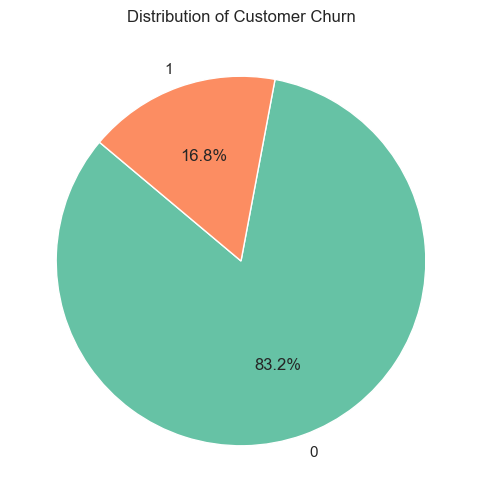

In [23]:
#dataset loaded
e_commerce = pd.read_excel(file, sheet_name="E Comm")

#inspect data
# print(e_commerce.shape)
# print(e_commerce.head())
# print(e_commerce.info())
# print(e_commerce.describe())

# - count missing values per column
print(e_commerce.isna().sum())

#visualize the churn column

churn_counts = e_commerce['Churn'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    churn_counts, 
    labels=churn_counts.index, 
    autopct='%1.1f%%', 
    colors = sns.color_palette('Set2')[0:len(churn_counts)],
    startangle=140
)

plt.title('Distribution of Customer Churn')
plt.show()

# 3. Data Preprocessing

## 3.1 Duplicate Records

Duplicate records occur when the same observation appears more than once in the dataset. If left untreated, duplicate records can bias a machine learning model by giving certain observations more influence than others. Therefore, the dataset is first checked for duplicate entries before proceeding with further preprocessing.

In [24]:
# Check for duplicate rows
duplicate_count = e_commerce.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


### Observation

The dataset contains **0 duplicate records**, indicating that each customer is represented by a unique observation. Therefore, no duplicate rows were removed, and the dataset can proceed to the next preprocessing stage without modification.

Duplicate records can bias machine learning models by causing certain observations to be overrepresented during training. Since no duplicates were detected, this issue does not affect the current dataset.

## 3.2 Missing Values

Missing values are common in real-world datasets and may arise due to incomplete data collection, human error, or system limitations. Most machine learning algorithms cannot handle missing values directly, making it necessary to identify and treat them before model training.

In this section, the dataset is examined for missing values, after which an appropriate imputation strategy will be selected based on the nature of each variable.

In [25]:
# Count missing values in each column
missing_values = e_commerce.isnull().sum()

# Calculate percentage of missing values
missing_percentage = (missing_values / len(e_commerce)) * 100

# Combine into one table
missing_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage (%)': missing_percentage
})

# Display only columns with missing values
missing_summary[missing_summary['Missing Values'] > 0]

,Missing Values,Percentage (%)
Tenure,264,4.689165
WarehouseToHome,251,4.458259
HourSpendOnApp,255,4.529307
OrderAmountHikeFromlastYear,265,4.706927
CouponUsed,256,4.547069
OrderCount,258,4.582593
DaySinceLastOrder,307,5.452931


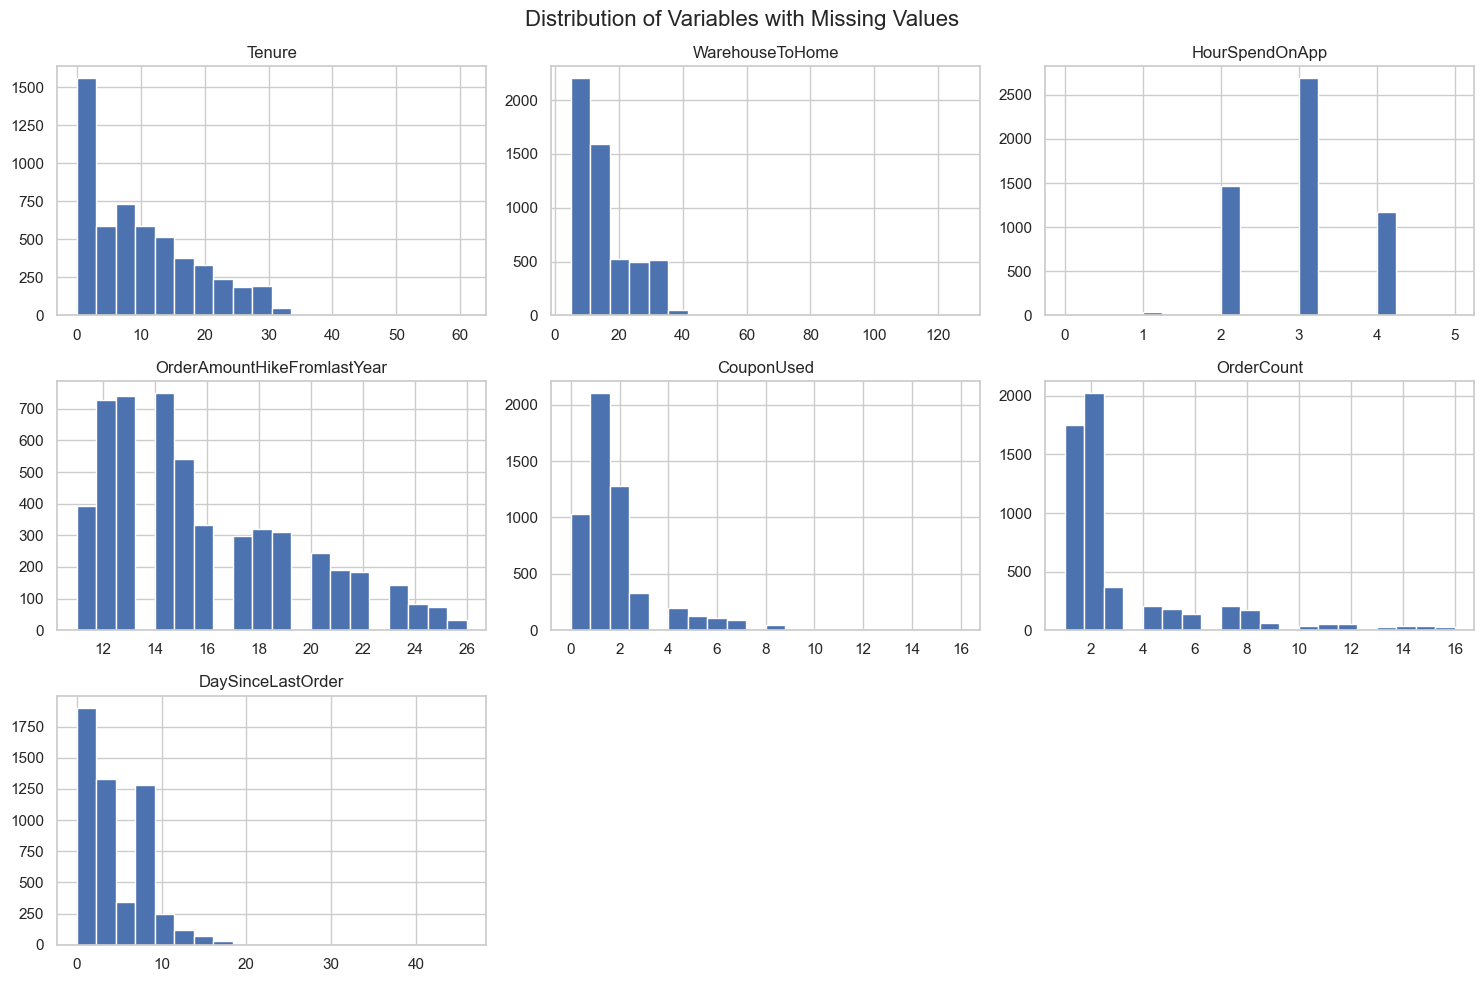

In [26]:
# Visualize the distributions of columns with missing values

columns_with_missing = [
    'Tenure',
    'WarehouseToHome',
    'HourSpendOnApp',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder'
]

e_commerce[columns_with_missing].hist(figsize=(15, 10), bins=20)

plt.suptitle("Distribution of Variables with Missing Values", fontsize=16)
plt.tight_layout()

plt.show()

In [27]:
# Check skewness

e_commerce[columns_with_missing].skew().sort_values()

HourSpendOnApp                -0.027213
Tenure                         0.736513
OrderAmountHikeFromlastYear    0.790785
DaySinceLastOrder              1.191000
WarehouseToHome                1.619154
OrderCount                     2.196414
CouponUsed                     2.545653
dtype: float64

### Observation

The missing values account for approximately **4–5%** of the dataset across seven numerical variables. Since the proportion of missing data is relatively small, removing these records would unnecessarily reduce the amount of training data available.

To determine the most appropriate imputation method, the distributions and skewness of the affected variables were examined. The results indicate that **HourSpendOnApp** is approximately normally distributed (skewness ≈ -0.03), while the remaining variables exhibit moderate to high positive skewness.

Therefore, the **mean** was used to impute missing values in *HourSpendOnApp*, whereas the **median** was used for all other variables because it is more robust to skewed distributions and outliers.

In [28]:
# Mean imputation for the approximately symmetric variable
e_commerce['HourSpendOnApp'] = e_commerce['HourSpendOnApp'].fillna(
    e_commerce['HourSpendOnApp'].mean()
)

# Median imputation for skewed variables
median_columns = [
    'Tenure',
    'WarehouseToHome',
    'OrderAmountHikeFromlastYear',
    'CouponUsed',
    'OrderCount',
    'DaySinceLastOrder'
]

for column in median_columns:
    e_commerce[column] = e_commerce[column].fillna(
        e_commerce[column].median()
    )

In [29]:
# Verify that all missing values have been handled

missing_after = e_commerce.isnull().sum()

print("Total missing values remaining:", missing_after.sum())

missing_after

Total missing values remaining: 0


CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

## 3.3 Data Type Verification

Before training a machine learning model, it is important to verify that every variable has the correct data type. Incorrect data types may lead to unexpected behaviour during preprocessing or model training.

This step confirms that numerical variables are stored as numeric types while categorical variables remain as object types before encoding.

In [30]:
# Display dataset information

e_commerce.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5630 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5630 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5630 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

### Observation

The dataset contains **5,630 observations** and **20 variables**, with no remaining missing values. All variables are stored using appropriate data types. Numerical variables are represented as either integer (`int64`) or floating-point (`float64`) values, while categorical variables are stored as strings.

Since the data types correctly reflect the nature of each variable, no type conversions were required before proceeding to the next preprocessing stage.

## 3.4 Removing Irrelevant Features

Some variables serve only as unique identifiers and do not contain meaningful information for predicting customer churn. Including such variables during model training may introduce unnecessary noise because machine learning algorithms may incorrectly interpret identification numbers as meaningful numerical values.

The `CustomerID` column uniquely identifies each customer but does not describe customer behaviour or purchasing patterns. Therefore, it is removed from the dataset before model development.

In [31]:
# Remove CustomerID since it does not contribute to prediction

e_commerce = e_commerce.drop(columns=['CustomerID'])

print("Remaining columns:", e_commerce.shape[1])

Remaining columns: 19


In [32]:
e_commerce.columns

Index(['Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

### Observation

The `CustomerID` column was successfully removed because it functions solely as a unique identifier and does not provide meaningful information for predicting customer churn. Removing this feature reduces unnecessary noise and prevents the model from learning relationships based on arbitrary identification numbers.

In [33]:
# Display unique values for all categorical variables

categorical_columns = [
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'Gender',
    'PreferedOrderCat',
    'MaritalStatus'
]

for column in categorical_columns:
    print(f"\n{column}")
    print("-" * len(column))
    print(e_commerce[column].value_counts())


PreferredLoginDevice
--------------------
PreferredLoginDevice
Mobile Phone    2765
Computer        1634
Phone           1231
Name: count, dtype: int64

PreferredPaymentMode
--------------------
PreferredPaymentMode
Debit Card          2314
Credit Card         1501
E wallet             614
UPI                  414
COD                  365
CC                   273
Cash on Delivery     149
Name: count, dtype: int64

Gender
------
Gender
Male      3384
Female    2246
Name: count, dtype: int64

PreferedOrderCat
----------------
PreferedOrderCat
Laptop & Accessory    2050
Mobile Phone          1271
Fashion                826
Mobile                 809
Grocery                410
Others                 264
Name: count, dtype: int64

MaritalStatus
-------------
MaritalStatus
Married     2986
Single      1796
Divorced     848
Name: count, dtype: int64


In [34]:
# Number of unique categories in each categorical feature

for column in categorical_columns:
    print(f"{column}: {e_commerce[column].nunique()} unique values")

PreferredLoginDevice: 3 unique values
PreferredPaymentMode: 7 unique values
Gender: 2 unique values
PreferedOrderCat: 6 unique values
MaritalStatus: 3 unique values


## 3.5 Data Consistency

The `PreferredPaymentMode` column contained abbreviated and full-text versions of the same payment methods. `CC` was treated as `Credit Card`, while `COD` was treated as `Cash on Delivery`.

Standardizing these values prevents the same payment method from being represented as separate categories during one-hot encoding.

In [35]:
# Standardize equivalent payment mode labels
e_commerce['PreferredPaymentMode'] = (
    e_commerce['PreferredPaymentMode']
    .replace({
        'CC': 'Credit Card',
        'COD': 'Cash on Delivery'
    })
)

# Verify the cleaned categories
e_commerce['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

## 3.6 Encoding Categorical Variables

Machine learning algorithms require numerical inputs. Since the categorical variables in this dataset are nominal and have no natural order, one-hot encoding was applied.

The `drop_first=True` option was used to remove one redundant category from each feature and reduce unnecessary duplication.

In [36]:
categorical_columns = [
    'PreferredLoginDevice',
    'PreferredPaymentMode',
    'Gender',
    'PreferedOrderCat',
    'MaritalStatus'
]

e_commerce = pd.get_dummies(
    e_commerce,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

print("Dataset shape after encoding:", e_commerce.shape)
e_commerce.head()


Dataset shape after encoding: (5630, 28)


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.000000,3,2,9,1,11.0,1.0,1.0,5.0,159.93,1,0,0,1,0,0,0,0,1,0,0,0,0,1
1,1,9.0,1,8.0,3.000000,4,3,7,1,15.0,0.0,1.0,0.0,120.90,0,1,0,0,0,1,1,0,0,1,0,0,0,1
2,1,9.0,1,30.0,2.000000,4,3,6,1,14.0,0.0,1.0,3.0,120.28,0,1,0,1,0,0,1,0,0,1,0,0,0,1
3,1,0.0,3,15.0,2.000000,4,5,8,0,23.0,0.0,1.0,3.0,134.07,0,1,0,1,0,0,1,0,1,0,0,0,0,1
4,1,0.0,1,12.0,2.931535,3,5,3,0,11.0,1.0,1.0,3.0,129.60,0,1,1,0,0,0,1,0,0,1,0,0,0,1


In [37]:
print("\nRemaining object columns:")
print(e_commerce.select_dtypes(include=['object', 'string']).columns.tolist())


Remaining object columns:
[]


### Observation

All categorical variables were successfully transformed into numerical features using one-hot encoding. The original categorical columns were replaced with binary indicator variables, and no object-type variables remain in the dataset. The dataset is therefore fully numerical and ready for subsequent machine learning preprocessing.

## Preprocessing Summary

The preprocessing stage prepared the dataset for machine learning by addressing data quality and consistency issues.

The following steps were completed:

- Verified that the dataset contained no duplicate records.
- Identified and imputed missing values using appropriate statistical measures.
- Confirmed that all variables had appropriate data types.
- Removed the `CustomerID` identifier as it does not contribute to churn prediction.
- Standardized inconsistent payment method labels.
- Converted all categorical variables into numerical format using one-hot encoding.

Following preprocessing, the dataset contains no missing values, no remaining categorical string variables, and is ready for feature engineering and model development.

# 4. Feature Engineering

## 4.1 Feature Selection

Before creating new features, it is useful to examine how strong the existing variable relate to the "Churn". This gives an early indication of which raw features are likely to be informative and provides a baseline to compare against once new features are added.
 

In [38]:
correlation_with_churn= e_commerce.corr(numeric_only= True)['Churn'].drop('Churn')
correlation_with_churn= correlation_with_churn.sort_values(key=abs, ascending=False)

correlation_with_churn



Tenure                                -0.337831
Complain                               0.250188
MaritalStatus_Single                   0.180847
DaySinceLastOrder                     -0.155871
PreferedOrderCat_Mobile Phone          0.154387
CashbackAmount                        -0.154118
MaritalStatus_Married                 -0.151024
PreferedOrderCat_Laptop & Accessory   -0.133353
PreferedOrderCat_Mobile                0.113364
PreferredLoginDevice_Mobile Phone     -0.111639
NumberOfDeviceRegistered               0.107939
SatisfactionScore                      0.105481
PreferedOrderCat_Grocery              -0.089575
CityTier                               0.084703
PreferredLoginDevice_Phone             0.078916
WarehouseToHome                        0.069544
PreferredPaymentMode_E wallet          0.055751
PreferedOrderCat_Others               -0.054903
PreferredPaymentMode_Credit Card      -0.047728
NumberOfAddress                        0.043931
PreferredPaymentMode_Debit Card       -0

### Observation 
The correlation values give the impression of feature relevance. Variables with very low correlation are not automatically discarded at this stage, since a weak linear correlation does not rule out a non-linear importance. Thus, this step serves as a refernce point before new features are introduced.

# 4.2 Creating New Features 

New features are created to capture behavioural patterens that are not directly repreesented by the raw columns. Each feature is built from raw, unscaled values, since scaling has not yet been appplied to the dataset. None of the new features are derived from 'Churn' so there is not a risk of target leakage.

In [39]:
# Orderd placed per month of tenure
e_commerce['OrderFrequency']= e_commerce['OrderCount'] /(e_commerce['Tenure']+1)

# Share of orders that used coupon
e_commerce['CouponUsageRate'] =e_commerce['CouponUsed'] / (e_commerce['OrderCount'] + 1)

# Days since last order relative to tenure — flags customers who have gone quiet relative to how long they have been a customer, not just in absolute days
e_commerce['RecencyRatio']=e_commerce['DaySinceLastOrder'] /(e_commerce['Tenure'] + 1)

# Engagement score (app usage with no. registered devices) 
e_commerce['EngagementScore'] = (
    e_commerce['HourSpendOnApp'] * e_commerce['NumberOfDeviceRegistered'])

new_features = ['OrderFrequency', 'CouponUsageRate','RecencyRatio','EngagementScore']
e_commerce[new_features].describe()


,OrderFrequency,CouponUsageRate,RecencyRatio,EngagementScore
count,5630.000000,5630.000000,5630.000000,5630.000000
mean,0.568800,0.418112,0.847606,11.036647
std,0.930812,0.316927,1.390631,4.595958
min,0.016393,0.000000,0.000000,0.000000
25%,0.111111,0.250000,0.166667,8.000000
50%,0.250000,0.461538,0.428571,12.000000
75%,0.866667,0.666667,1.000000,15.000000
max,15.000000,4.666667,46.000000,25.000000


### Observation

The 4 features created:

- OrderFrequency — orders per month of tenure
- CouponUsageRate — proportion of orders that used a coupon
- RecencyRatio — days since last order, scaled by tenure
- EngagementScore — app usage combined with device count

Each feature reframes an existing raw variable as a rate rather than a raw count, which is generally more comparable across customers with very different tenures.

## 4.3. Removing Redundant Features

Highly correlated features can introduce multicollinearity, where two variables provide largely the same information. This is checked using a correlation threshold of 0.85, a common rule of thumb, and any candidate pairs are reviewed manually before removal rather than dropped automatically.


In [40]:
import numpy as np

corr_matrix = e_commerce.drop(columns=['Churn']).corr(numeric_only=True).abs()
upper_triangle= corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

redundant_candidates = [
    column for column in upper_triangle.columns if any(upper_triangle[column] > 0.85)
]

print("Feature pairs above 0.85 correlation:")
for column in redundant_candidates:
    high_corr_with = upper_triangle.index[upper_triangle[column] > 0.85].tolist()
    print(f"  {column} <-> {high_corr_with}")

Feature pairs above 0.85 correlation:


## Observation 
No feature pairs exceeded the 0.85 correlation threshold. All 4 engineering features each capture a distinct behavioural signal, so no features were removed here. 

## 4.4 Correlation Analysis 
 A heatmap of all numeric features, including  the newly engineered ones, gives a visual overview of relationships across the full feature set and highlights how the new features relate to Churn compared to the original variables.


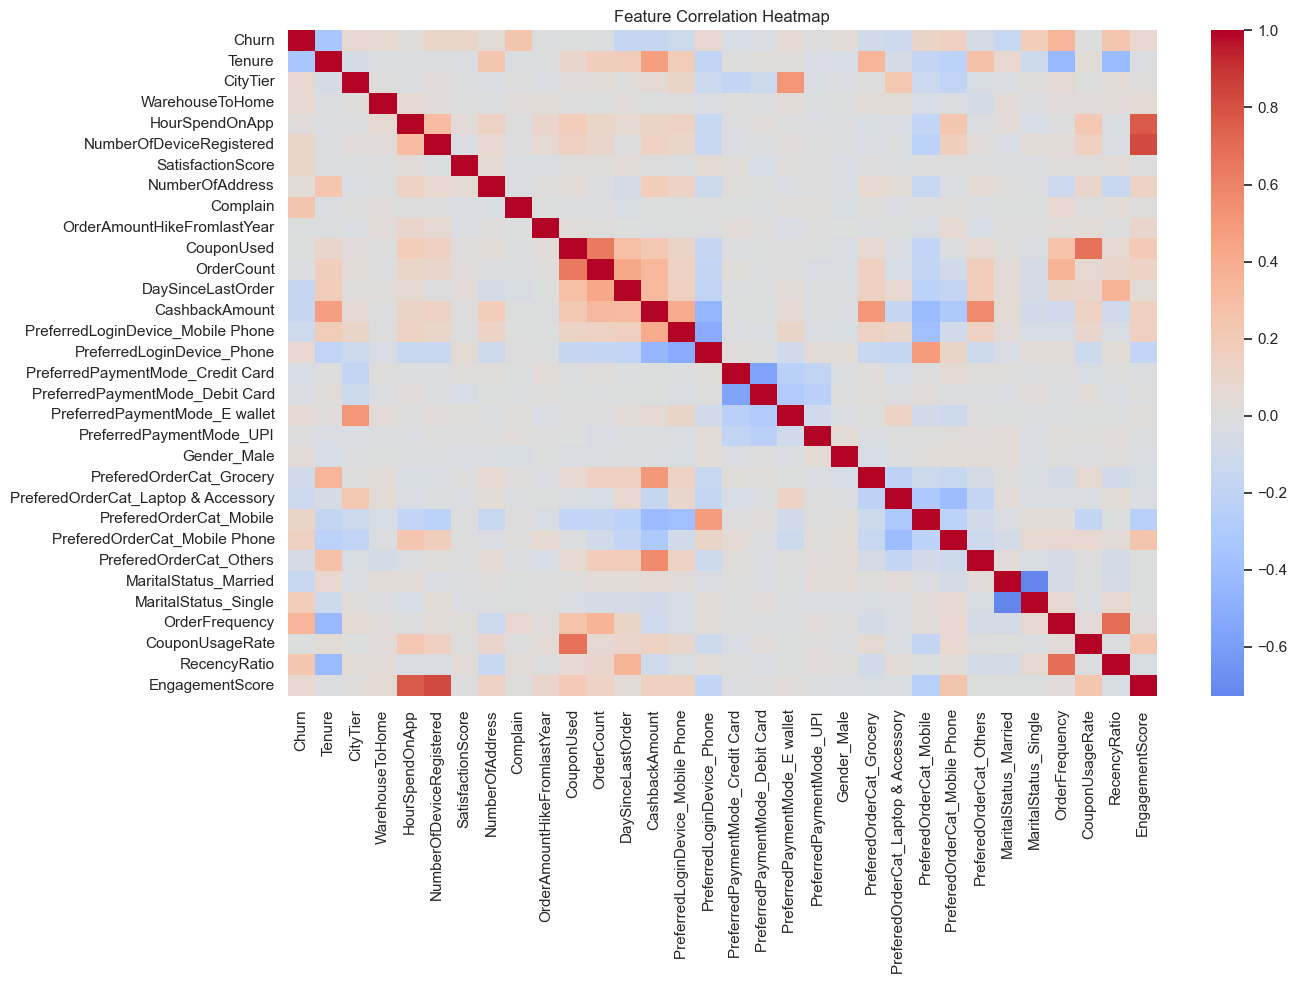

In [41]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    e_commerce.corr(numeric_only=True),
    cmap='coolwarm',
    center=0,
    annot=False
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# 4.5 Final Feature Matrix

The dataset is ready to be split into the final feature matrix X and target vector y, now that feature selection, creation, and redundancy checks are complete.Now to hand off for train/test splitting and scaling.

In [42]:
X= e_commerce.drop(columns= ['Churn'])
Y= e_commerce['Churn']
print("Final feature matrix shape:", X.shape)
print("Number of features:", X.shape[1])
X.head()

Final feature matrix shape: (5630, 31)
Number of features: 31


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,OrderFrequency,CouponUsageRate,RecencyRatio,EngagementScore
0,4.0,3,6.0,3.000000,3,2,9,1,11.0,1.0,1.0,5.0,159.93,1,0,0,1,0,0,0,0,1,0,0,0,0,1,0.2,0.5,1.0,9.000000
1,9.0,1,8.0,3.000000,4,3,7,1,15.0,0.0,1.0,0.0,120.90,0,1,0,0,0,1,1,0,0,1,0,0,0,1,0.1,0.0,0.0,12.000000
2,9.0,1,30.0,2.000000,4,3,6,1,14.0,0.0,1.0,3.0,120.28,0,1,0,1,0,0,1,0,0,1,0,0,0,1,0.1,0.0,0.3,8.000000
3,0.0,3,15.0,2.000000,4,5,8,0,23.0,0.0,1.0,3.0,134.07,0,1,0,1,0,0,1,0,1,0,0,0,0,1,1.0,0.0,3.0,8.000000
4,0.0,1,12.0,2.931535,3,5,3,0,11.0,1.0,1.0,3.0,129.60,0,1,1,0,0,0,1,0,0,1,0,0,0,1,1.0,0.5,3.0,8.794605


## Feature Engineering Summary

This stage is built on the cleaned, encoded dataset from preprocessing by:

- Reviewing correlation of existing features with Churn as a baseline
- Creating four new behavioural features: OrderFrequency, CouponUsageRate, RecencyRatio, and EngagementScore
- Checking for and addressing multicollinearity among numeric features
- Visualizing the full correlation structure of the dataset
- Producing a final feature matrix X and target y for modeling

Now, the dataset is now ready for the modeling team to perform the train/test split and feature scaling.

# 5 Train/test Split and Feature scaling



## 5.1 Train/test Split
In this section, the dataset would be split into two sets:
 - train set -Used mainly for training data
 - Test set- used to check for overfitting or underfitting data.

To ensure that there are equal proportions in each set we shall use stratify=y, this ensures that the model is not biased towards one type of output or the other.

The dataset will be split in a 60/40 split, for train and test sets respectively

In [47]:
from sklearn.model_selection import train_test_split
X_test, X_train, y_test, y_train = train_test_split(#creates a train and a test
    X, Y, test_size=0.6, random_state=RANDOM_STATE, stratify=Y
)

## Effect
Two sets are poduced, though randomly but due to random state can be reproduced over multiple funtion calls or code runs ensuring that the results do not change as we train and rerun the code.

It is also stratified accordinf to the proportions of the features in Y ensuring that they are proprtional in each set.

## 5.2 Feature scaling

The training set is fit on but both sets are transformed, the test set is not fit as it is used to represent new, unseen data for the model. The StandardScaler takes the mean and standard deviation from the training set and then applies that same scaling to the rest of the data. 

In [48]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

numeric_columns=["Tenure",
                "CityTier",
            	"WarehouseToHome",
            	"HourSpendOnApp",
            	"NumberOfDeviceRegistered",
            	"SatisfactionScore",
            	"NumberOfAddress",
            	"Complain",	
                "OrderAmountHikeFromlastYear",	
                "CouponUsed",	
                "OrderCount",	
                "DaySinceLastOrder",	
                "CashbackAmount",		
                "OrderFrequency",
            	"CouponUsageRate",	
                "RecencyRatio",	
                "EngagementScore"]# a set of numeric featurea which would be used for scaling

X_train_scaled=X_train # we must copy the sets into the new scaled model so if in case of an errror we can revert
X_test_scaled=X_test
X_train_scaled[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])# the scaling happens only on the numeric columns, binarynot inclusive as that would return the same arrange ment of values
X_test_scaled[numeric_columns] = scaler.transform(X_test[numeric_columns])


## 5.3 Final train/test sets

The dataset is now ready to be used to train the chosen model.

Feature scaling and train/test split are complete

In [50]:
print(f"Shape of train set: {X_train_scaled.shape}")
print(f"Shape of test set: {X_test_scaled.shape}")

print("First 5 rows of train set")
X_train_scaled.head()



Shape of train set: (3378, 31)
Shape of test set: (2252, 31)
First 5 rows of train set


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,OrderFrequency,CouponUsageRate,RecencyRatio,EngagementScore
3272,0.474317,-0.711028,-0.791063,0.086799,-1.620080,0.684219,-0.466057,-0.648937,2.543613,-0.384991,0.376749,1.011807,-0.204954,0,0,1,0,0,0,0,0,1,0,0,0,0,0,-0.329348,-0.704270,-0.245327,-1.099081
476,0.353411,-0.711028,0.776570,-1.344758,0.301490,-0.044665,1.095014,-0.648937,-0.475668,-0.384991,-0.680862,-1.269063,-0.540866,0,0,1,0,0,0,1,0,1,0,0,0,0,1,-0.552150,0.275934,-0.669624,-0.664483
60,-0.492929,-0.711028,0.535396,-0.011212,-0.659295,0.684219,-0.856325,-0.648937,-0.750148,-0.937454,-0.680862,0.441590,-1.016842,0,1,1,0,0,0,0,0,0,1,0,0,0,0,-0.470637,-1.357739,0.012283,-0.491816
2758,-1.218363,-0.711028,-0.911651,-1.344758,-0.659295,-0.044665,1.095014,1.540982,0.896732,-0.937454,-0.680862,-0.698846,-0.768268,0,1,0,0,0,1,1,0,0,0,1,0,1,0,0.507518,-1.357739,0.921492,-1.099081
3392,-0.734740,1.473468,-0.067540,1.518357,0.301490,-0.044665,1.095014,-0.648937,-1.024628,1.824862,1.786897,1.011807,0.409866,1,0,0,0,0,1,1,0,0,0,0,0,1,0,1.192227,0.457454,0.603269,1.073908


In [51]:
print("First 5 rows of test set")
X_test_scaled.head()

First 5 rows of test set


,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,PreferredLoginDevice_Mobile Phone,PreferredLoginDevice_Phone,PreferredPaymentMode_Credit Card,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single,OrderFrequency,CouponUsageRate,RecencyRatio,EngagementScore
1211,2.166997,-0.711028,-0.911651,-0.011212,0.301490,-1.502434,1.875550,-0.648937,1.171213,-0.937454,-0.680862,-0.128628,-1.035979,0,1,0,0,0,0,1,0,0,1,0,0,1,0,-0.594311,-1.357739,-0.559892,0.145203
1354,-0.130212,-0.711028,2.103029,0.086799,-0.659295,-0.044665,1.095014,-0.648937,-0.750148,-0.937454,1.434360,0.726698,-0.511753,1,0,1,0,0,0,1,0,1,0,0,0,1,0,0.165164,-1.357739,-0.112734,-0.447184
4350,1.925185,-0.711028,-1.032238,1.518357,1.262275,-0.044665,-0.856325,-0.648937,-0.201188,3.482252,3.197044,1.582025,3.002492,1,0,0,1,0,0,1,0,0,0,0,1,1,0,-0.126471,0.652936,-0.374973,1.943104
4801,-0.492929,1.473468,-0.429302,0.086799,0.301490,0.684219,-0.466057,-0.648937,-0.201188,0.719936,1.081823,-0.128628,0.259214,0,0,0,1,0,0,1,0,1,0,0,0,1,0,0.344493,0.042553,-0.215020,0.204713
1470,-1.218363,-0.711028,-0.188127,-1.344758,0.301490,0.684219,-0.856325,-0.648937,0.896732,0.167473,0.376749,-0.413737,-1.095832,0,1,0,0,0,1,0,0,0,1,0,0,1,0,3.931061,-0.050800,1.717050,-0.664483


Class distribution for Churn in Train set
Churn
0    0.831557
1    0.168443
Name: proportion, dtype: float64
 
Class distribution for Churn in Test set
Churn
0    0.831705
1    0.168295
Name: proportion, dtype: float64


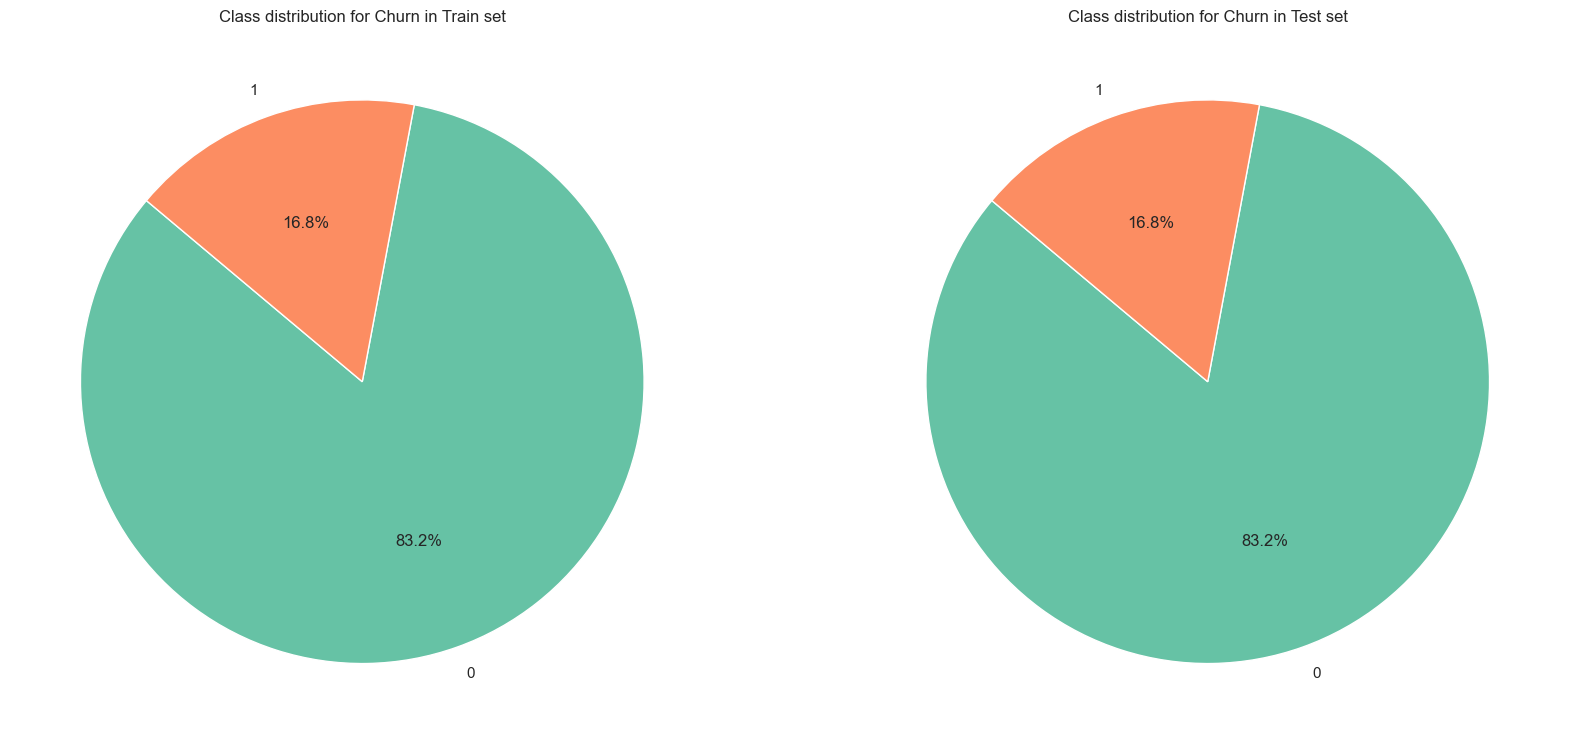

In [60]:
#prove stratify
print("Class distribution for Churn in Train set")
print(y_train.value_counts(normalize=True))
print(" ")
print("Class distribution for Churn in Test set")
print(y_test.value_counts(normalize=True))
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(20,10))
ax1.pie(
    y_train.value_counts(), 
    labels=y_train.value_counts().index, 
    autopct='%1.1f%%', 
    colors = sns.color_palette('Set2')[0:len(y_train.value_counts())],
    startangle=140,
    
)
ax1.set_title("Class distribution for Churn in Train set")

ax2.pie(
    y_test.value_counts(), 
    labels=y_test.value_counts().index, 
    autopct='%1.1f%%', 
    colors = sns.color_palette('Set2')[0:len(y_test.value_counts())],
    startangle=140,
    
)
ax2.set_title("Class distribution for Churn in Test set")

plt.show()

## Train/test split and Feature Engineering summary

After split we realize that now number of rows of traing set is 3378

$$
\implies 0.6 \cdot 5630 = 3378
$$

And number of tuples of the test set = 2252

$$
\implies 0.4 \cdot 5630 = 2252
$$

This proves that it is a 60/40 split

The Ratios of the classes of the y values of both the test and train sets are equal, and are also equal to that of the origional dataset, hence there will be no case of the model learning only one type of class, reducing overfitting and bias.

Now it is ready to be trained